In [1]:
### Cell 1: Imports ###
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
### Cell 2: Load and Preprocess Data ###
# UPDATED FOR 3D: Added 'z' to input and 'Uz' to output
df = pd.read_csv('/kaggle/input/trapezium3d-fluid-flow-simulation/concatenated_data_all_steps_3D.csv')
df_subset = df.groupby('time', group_keys=False).head(50)
print(f"Original shape: {df.shape}")
print(f"Subset shape: {df_subset.shape}")

# Optional — check how many unique time steps and how many samples per step
print(f"Unique time steps: {df_subset['time'].nunique()}")
print(df_subset['time'].value_counts().head())

X = df_subset[['time', 'x', 'y', 'z']].values
Y = df_subset[['Ux', 'Uy', 'Uz', 'p']].values

X_all = df[['time', 'x', 'y', 'z']].values
Y_all = df[['Ux', 'Uy', 'Uz', 'p']].values

y_scaler = StandardScaler()
Y_scaled = y_scaler.fit_transform(Y)
Y_scaled_all = y_scaler.transform(Y_all)

x_train_tensor = torch.tensor(X, dtype=torch.float32)
y_train_tensor = torch.tensor(Y_scaled, dtype=torch.float32)
y_all_tensor = torch.tensor(Y_scaled_all,dtype=torch.float32)

print(f"Input shape: {x_train_tensor.shape}")
print(f"Output shape: {y_train_tensor.shape}")

Original shape: (202000, 9)
Subset shape: (5050, 9)
Unique time steps: 101
time
10.0    50
0.0     50
0.1     50
0.2     50
0.3     50
Name: count, dtype: int64
Input shape: torch.Size([5050, 4])
Output shape: torch.Size([5050, 4])


In [3]:
# ### Cell 3: Visualization Functions ###
# def plot_mesh(x, y):
#     # This remains a 2D plot, showing a projection or slice
#     fig = plt.figure(figsize=(12, 4))
#     ax = fig.add_subplot(111)
#     ax.scatter(x, y, c='k', s=0.1)
#     ax.set_title('Mesh (2D Slice/Projection)')
#     ax.set_aspect(1)
#     plt.show()

# # UPDATED FOR 3D: Added 'w' (for Uz)
# def plot_flow_variables(x, y, u, v, w, p):
#     variables = [u, v, w, p]
#     titles = ['Ux', 'Uy', 'Uz', 'p'] # Added U_z
#     n_variables = len(variables)
#     fig, ax = plt.subplots(n_variables, 1, figsize=(12, 14)) # Increased figure size
#     fig.tight_layout(pad=5.0)
    
#     # This still uses tricontourf, so it plots a 2D slice
#     for i, variable in enumerate(variables):
#         if x.shape[0] > 0 and y.shape[0] > 0 and variable.shape[0] > 0:
#             try:
#                 contour = ax[i].tricontourf(x, y, variable, levels=50, cmap='jet')
#                 ax[i].set_aspect(1)
#                 fig.colorbar(contour, ax=ax[i])
#                 ax[i].set_title(titles[i])
#             except Exception as e:
#                 ax[i].set_title(f"{titles[i]} - Plotting Error: {e}")
#         else:
#             ax[i].set_title(f"{titles[i]} - No data to plot")
#     plt.show()

In [4]:
### Cell 4: Plot Initial Data (at t=0.1 and a z-slice) ###
# UPDATED FOR 3D: Plotting a 2D slice from the 3D data
# df_t1 = df[df['time'] == 0.1]
# # Plot a slice at the median z-value for this timestep
# z_slice_val = df_t1['z'].median()
# df_slice = df_t1[df_t1['z'] == z_slice_val]

# print(f"Plotting 2D slice at t=0.1, z={z_slice_val}")
# plot_mesh(df_slice['x'].values, df_slice['y'].values)
# plot_flow_variables(df_slice['x'].values, df_slice['y'].values, 
#                     df_slice['Ux'].values, df_slice['Uy'].values, 
#                     df_slice['Uz'].values, df_slice['p'].values)

In [3]:
### Cell 5: Define PDE Loss (Unsteady Laminar 3D Navier-Stokes) ###
nu = 5e-6 

# UPDATED FOR 3D: Added 'z' coordinate and 'w' (Uz) velocity
def pde_loss(t, x, y, z, pred):
    # u, v, w, p
    u, v, w, p = pred[:, 0:1], pred[:, 1:2], pred[:, 2:3], pred[:, 3:4]

    # First derivatives
    u_t = torch.autograd.grad(u, t, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_x = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_y = torch.autograd.grad(u, y, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_z = torch.autograd.grad(u, z, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    
    v_t = torch.autograd.grad(v, t, grad_outputs=torch.ones_like(v), create_graph=True)[0]
    v_x = torch.autograd.grad(v, x, grad_outputs=torch.ones_like(v), create_graph=True)[0]
    v_y = torch.autograd.grad(v, y, grad_outputs=torch.ones_like(v), create_graph=True)[0]
    v_z = torch.autograd.grad(v, z, grad_outputs=torch.ones_like(v), create_graph=True)[0]

    w_t = torch.autograd.grad(w, t, grad_outputs=torch.ones_like(w), create_graph=True)[0]
    w_x = torch.autograd.grad(w, x, grad_outputs=torch.ones_like(w), create_graph=True)[0]
    w_y = torch.autograd.grad(w, y, grad_outputs=torch.ones_like(w), create_graph=True)[0]
    w_z = torch.autograd.grad(w, z, grad_outputs=torch.ones_like(w), create_graph=True)[0]
    p_x = torch.autograd.grad(p, x, grad_outputs=torch.ones_like(p), create_graph=True)[0]
    p_y = torch.autograd.grad(p, y, grad_outputs=torch.ones_like(p), create_graph=True)[0]
    p_z = torch.autograd.grad(p, z, grad_outputs=torch.ones_like(p), create_graph=True)[0]

    # Second derivatives (Laplacian)
    u_xx = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]
    u_yy = torch.autograd.grad(u_y, y, grad_outputs=torch.ones_like(u_y), create_graph=True)[0]
    u_zz = torch.autograd.grad(u_z, z, grad_outputs=torch.ones_like(u_z), create_graph=True)[0]
    
    v_xx = torch.autograd.grad(v_x, x, grad_outputs=torch.ones_like(v_x), create_graph=True)[0]
    v_yy = torch.autograd.grad(v_y, y, grad_outputs=torch.ones_like(v_y), create_graph=True)[0]
    v_zz = torch.autograd.grad(v_z, z, grad_outputs=torch.ones_like(v_z), create_graph=True)[0]

    w_xx = torch.autograd.grad(w_x, x, grad_outputs=torch.ones_like(w_x), create_graph=True)[0]
    w_yy = torch.autograd.grad(w_y, y, grad_outputs=torch.ones_like(w_y), create_graph=True)[0]
    w_zz = torch.autograd.grad(w_z, z, grad_outputs=torch.ones_like(w_z), create_graph=True)[0]

    # Continuity equation
    cont = u_x + v_y + w_z
    # Momentum equations
    # x-momentum
    f = u_t + (u * u_x + v * u_y + w * u_z) + p_x - nu * (u_xx + u_yy + u_zz)
    # y-momentum
    g = v_t + (u * v_x + v * v_y + w * v_z) + p_y - nu * (v_xx + v_yy + v_zz)
    # z-momentum
    h = w_t + (u * w_x + v * w_y + w * w_z) + p_z - nu * (w_xx + w_yy + w_zz)

    # Calculate losses
    f_loss = (f ** 2).mean()
    g_loss = (g ** 2).mean()
    h_loss = (h ** 2).mean()
    cont_loss = (cont ** 2).mean()
    
    return f_loss + g_loss + h_loss + cont_loss

In [4]:
### Cell 6: Define the Model (Standard PINN) ###
class PINN3D(nn.Module):
    def __init__(self, input_dim=4, output_dim=4, hidden_dim=256, num_layers=8):
        super(PINN3D, self).__init__()
        layers = []
        layers.append(nn.Linear(input_dim, hidden_dim))
        for _ in range(num_layers - 2):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
        layers.append(nn.Linear(hidden_dim, output_dim))

        self.layers = nn.ModuleList(layers)
        self.activation = torch.tanh  # recommended for PINNs
        
        # Xavier init (important for PINN stability)
        self._initialize_weights()

    def _initialize_weights(self):
        for layer in self.layers:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                if layer.bias is not None:
                    nn.init.zeros_(layer.bias)

    def forward(self, x):
        # Simple forward pass without Fourier embedding
        for layer in self.layers[:-1]:
            x = self.activation(layer(x))
        return self.layers[-1](x)

In [7]:
### Cell 6: Define the Model (PirateNet) ###
# This class definition is generic and does not need changes
# The input_dim and output_dim are set during instantiation
# class PirateNetBlock(nn.Module):
#     def __init__(self, hidden_dim):
#         super(PirateNetBlock, self).__init__()
#         self.dense1 = nn.Linear(hidden_dim, hidden_dim)
#         self.dense2 = nn.Linear(hidden_dim, hidden_dim)
#         self.dense3 = nn.Linear(hidden_dim, hidden_dim)
#         self.alpha = nn.Parameter(torch.zeros(1))

#     def forward(self, x, u, v):
#         f = F.tanh(self.dense1(x))
#         z1 = f * u + (1 - f) * v
#         g = F.tanh(self.dense2(z1))
#         z2 = g * u + (1 - g) * v
#         h = F.tanh(self.dense3(z2))
#         return self.alpha * h + (1 - self.alpha) * x

# class PirateNet(nn.Module):
#     def __init__(
#         self,
#         input_dim,
#         output_dim,
#         num_blocks,
#         hidden_dim=256,
#         s=1.0,
#         activation=F.tanh,
#     ):
#         super(PirateNet, self).__init__()
#         self.input_dim = input_dim
#         self.output_dim = output_dim
#         self.num_blocks = num_blocks
#         self.hidden_dim = hidden_dim
#         self.s = s
#         self.activation = activation
#         self.B = nn.Parameter(torch.randn(input_dim, hidden_dim // 2) * s)
#         self.embedding = lambda x: torch.cat(
#             [torch.cos(torch.matmul(x, self.B)), torch.sin(torch.matmul(x, self.B))],
#             dim=-1,
#         )
#         self.blocks = nn.ModuleList(
#             [PirateNetBlock(hidden_dim) for _ in range(num_blocks)]
#         )
#         self.U = nn.Linear(hidden_dim, hidden_dim)
#         self.V = nn.Linear(hidden_dim, hidden_dim)
#         self.final_layer = nn.Linear(hidden_dim, output_dim, bias=False)
#         print(f"Final layer weights shape: {self.final_layer.weight.data.shape}")
#         self.initialize_weights()

#     def initialize_weights(self):
#         for module in self.modules():
#             if isinstance(module, nn.Linear):
#                 torch.nn.init.xavier_uniform_(module.weight)
#                 if module.bias is not None:
#                     module.bias.data.zero_()

#     def forward(self, x):
#         x = self.embedding(x)
#         u = self.activation(self.U(x))
#         v = self.activation(self.V(x))
#         for block in self.blocks:
#             x = block(x, u, v)
#         return self.final_layer(x)

In [5]:
# %%time

# ### Cell 7: Training Loop (with Early Stopping) ###
# def train_model(model, optimizer, iterations, x_train, y_train, val_x, val_y):
#     logs={"iteration": [], "loss_from_pde": [], "loss_from_data": [], "total_loss": [], "val_loss": []}
#     best_val_loss=float('inf')
#     patience=50 
#     patience_counter=0
    
#     def closure():
#         # UPDATED FOR 3D: Unpack t, x, y, z
#         t, x, y, z = x_train[:, 0:1], x_train[:, 1:2], x_train[:, 2:3], x_train[:, 3:4]
#         t.requires_grad_(True)
#         x.requires_grad_(True)
#         y.requires_grad_(True)
#         z.requires_grad_(True) # Set requires_grad for z
        
#         # UPDATED FOR 3D: Catenate t, x, y, z
#         input_tensor = torch.cat([t, x, y, z], dim=1)
#         pred = model(input_tensor)
        
#         optimizer.zero_grad()
        
#         loss_from_data = F.mse_loss(pred, y_train)
        
#         # UPDATED FOR 3D: Pass z to pde_loss
#         loss_from_pde = pde_loss(t, x, y, z, pred)
        
#         loss = 0.01*loss_from_pde + loss_from_data
#         loss.backward()
        
#         closure.iteration += 1
#         model.eval()
#         with torch.no_grad():
#             val_pred = model(val_x)
#             val_loss = F.mse_loss(val_pred, val_y)
#         model.train()
        
#         logs["iteration"].append(closure.iteration)
#         logs["loss_from_pde"].append(loss_from_pde.item())
#         logs["loss_from_data"].append(loss_from_data.item())
#         logs["total_loss"].append(loss.item())
#         logs["val_loss"].append(val_loss.item())
        
#         if closure.iteration % 100 == 0:
#             print(
#                 f"Iteration {closure.iteration}. PDE loss: {loss_from_pde.item():.4f}, Data loss: {loss_from_data.item():.4f}, Val loss: {val_loss.item():.4f}"
#             )
            
#         closure.best_val_loss = best_val_loss
#         closure.patience_counter = patience_counter
        
#         if val_loss.item() < closure.best_val_loss:
#             closure.best_val_loss = val_loss.item()
#             closure.patience_counter = 0
#             torch.save(model.state_dict(), 'best_model_adam.pth')
#         else:
#             closure.patience_counter += 1
            
#         return loss
    
#     closure.iteration = 0
#     closure.best_val_loss = best_val_loss
#     closure.patience_counter = patience_counter
    
#     try:
#         if isinstance(optimizer, torch.optim.LBFGS):
#             # optimizer.step(closure)
#             optimizer.zero_grad()
#             loss = closure()
#             optimizer.step()
#         else:
#             for iteration in range(iterations):
#                 loss = optimizer.step(closure)
#                 if closure.patience_counter >= patience:
#                     print(f"Early stopping at iteration {closure.iteration}")
#                     break
            
#     except KeyboardInterrupt: 
#         print('Training stopped manually')
    
#     model.load_state_dict(torch.load('best_model_adam.pth'))
#     return logs
    
# # UPDATED FOR 3D: Input dim is 4 (t, x, y, z)
# input_dim = 4
# # UPDATED FOR 3D: Output dim is 4 (u, v, w, p)
# output_dim = 4
# n_layers = 8
# layer_dim = 256

# ### Cell 8: Setup Training ###
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# print(f"Using device: {device}")

# torch.manual_seed(42)
# indices = torch.randperm(x_train_tensor.size(0))
# train_size = int(0.8 * x_train_tensor.size(0))

# x_train = x_train_tensor[indices[:train_size]].to(device)
# y_train = y_train_tensor[indices[:train_size]].to(device)
# x_val = x_train_tensor[indices[train_size:]].to(device)
# y_val = y_train_tensor[indices[train_size:]].to(device)

# model = PINN3D(
#     input_dim=input_dim,
#     output_dim=output_dim,
#     hidden_dim=layer_dim,
#     num_layers=n_layers
# ).to(device)


# ### Cell 9: Train with Adam ###
# lr = 0.001
# iterations = 3000 
# optimizer_adam = optim.Adam(model.parameters(), lr=lr)
# logs_adam = train_model(model, optimizer_adam, iterations, x_train, y_train, x_val, y_val)

In [17]:
def train_pinn_with_curriculum(model, optimizer, iterations, x_train, y_train, val_x, val_y, pde_loss_fn):
    """
    Trains a PINN with curriculum weighting on the PDE loss.
    λ starts small and grows during training to balance data fitting and physics consistency.
    """

    logs = {
        "iteration": [], 
        "data_loss": [], 
        "pde_loss": [], 
        "total_loss": [], 
        "val_loss": []
    }

    best_val_loss = float('inf')
    patience = 500
    patience_counter = 0

    # Curriculum parameters
    λ_start = 1e-4
    λ_end = 1.0
    λ_growth = (λ_end / λ_start) ** (1 / iterations)  # geometric growth rate
    λ = λ_start

    for iteration in range(1, iterations + 1):
        model.train()
        optimizer.zero_grad()

        # Split inputs (t, x, y, z)
        t, x, y, z = (
            x_train[:, 0:1],
            x_train[:, 1:2],
            x_train[:, 2:3],
            x_train[:, 3:4],
        )
        t.requires_grad_(True)
        x.requires_grad_(True)
        y.requires_grad_(True)
        z.requires_grad_(True)

        # Forward pass
        pred = model(torch.cat([t, x, y, z], dim=1))

        # Compute losses
        data_loss = F.mse_loss(pred, y_train)
        pde_loss = pde_loss_fn(t, x, y, z, pred)
        total_loss = data_loss + λ * pde_loss

        total_loss.backward()
        optimizer.step()

        # Validation
        model.eval()
        with torch.no_grad():
            val_pred = model(val_x)
            val_loss = F.mse_loss(val_pred, val_y)

        # Log values
        logs["iteration"].append(iteration)
        logs["data_loss"].append(data_loss.item())
        logs["pde_loss"].append(pde_loss.item())
        logs["total_loss"].append(total_loss.item())
        logs["val_loss"].append(val_loss.item())

        if iteration % 100 == 0 or iteration == 1:
            print(
                f"Iter {iteration:4d} | λ={λ:.6f} | "
                f"Data Loss={data_loss.item():.4e}, PDE Loss={pde_loss.item():.4e}, "
                f"Val Loss={val_loss.item():.4e}"
            )

        # Early stopping logic
        if val_loss.item() < best_val_loss:
            best_val_loss = val_loss.item()
            patience_counter = 0
            torch.save(model.state_dict(), "best_pinn_model_curriculum.pth")
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f"Early stopping at iteration {iteration}")
            break

        # Update λ (grow gradually)
        λ *= λ_growth
        λ = min(λ, λ_end)  # clamp to max

    # Load best model
    model.load_state_dict(torch.load("best_pinn_model_curriculum.pth"))
    print("✅ Best model loaded from checkpoint.")
    return logs

In [18]:
import matplotlib.pyplot as plt

def plot_training_logs(logs, title="ANN Training Progress"):
    """
    Plots training and validation loss curves from the logs dictionary.
    Args:
        logs: dict with keys ['iteration', 'train_loss', 'val_loss']
        title: plot title
    """
    plt.figure(figsize=(8, 5))
    plt.plot(logs["iteration"], logs["data_loss"], label="MSE Loss", linewidth=2)
    plt.plot(logs["iteration"], logs["pde_loss"], label="PDE Loss", linewidth=2)
    plt.plot(logs["iteration"], logs["total_loss"], label="Total Loss", linewidth=2)
    plt.plot(logs["iteration"], logs["val_loss"], label="Validation Loss", linewidth=2)
    plt.xlabel("Iteration", fontsize=12)
    plt.ylabel("MSE Loss", fontsize=12)
    plt.title(title, fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


In [19]:

# UPDATED FOR 3D: Input dim is 4 (t, x, y, z)
input_dim = 4
# UPDATED FOR 3D: Output dim is 4 (u, v, w, p)
output_dim = 4
n_layers = 8
layer_dim = 256

### Cell 8: Setup Training ###
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

torch.manual_seed(42)
indices = torch.randperm(x_train_tensor.size(0))
train_size = int(0.8 * x_train_tensor.size(0))

x_train = x_train_tensor[indices[:train_size]].to(device)
y_train = y_train_tensor[indices[:train_size]].to(device)
x_val = x_train_tensor[indices[train_size:]].to(device)
y_val = y_train_tensor[indices[train_size:]].to(device)

model = PINN3D(
    input_dim=input_dim,
    output_dim=output_dim,
    hidden_dim=layer_dim,
    num_layers=n_layers
).to(device)

lr = 0.001
iterations = 3000 
optimizer_adam = optim.Adam(model.parameters(), lr=lr)
logs_adam = train_pinn_with_curriculum(model, optimizer_adam, iterations, x_train, y_train, x_val, y_val,pde_loss_fn=pde_loss)

Using device: cuda
Iter    1 | λ=0.000100 | Data Loss=1.0088e+00, PDE Loss=7.3880e-02, Val Loss=4.7354e+00
Iter  100 | λ=0.000136 | Data Loss=3.5969e-01, PDE Loss=2.3037e+01, Val Loss=3.4935e-01
Iter  200 | λ=0.000184 | Data Loss=3.0385e-01, PDE Loss=3.1475e+01, Val Loss=2.9902e-01
Iter  300 | λ=0.000250 | Data Loss=3.1137e-01, PDE Loss=4.8197e+01, Val Loss=2.7421e-01
Iter  400 | λ=0.000340 | Data Loss=2.1448e-01, PDE Loss=5.0654e+01, Val Loss=2.0458e-01
Iter  500 | λ=0.000463 | Data Loss=2.1227e-01, PDE Loss=3.0113e+01, Val Loss=1.9363e-01
Iter  600 | λ=0.000629 | Data Loss=1.6974e-01, PDE Loss=1.6411e+01, Val Loss=1.6608e-01
Iter  700 | λ=0.000855 | Data Loss=1.5870e-01, PDE Loss=1.5621e+01, Val Loss=1.5259e-01
Iter  800 | λ=0.001162 | Data Loss=2.0705e-01, PDE Loss=2.9821e+01, Val Loss=2.0193e-01
Iter  900 | λ=0.001580 | Data Loss=1.2990e-01, PDE Loss=1.1753e+01, Val Loss=1.3734e-01
Iter 1000 | λ=0.002148 | Data Loss=1.0775e-01, PDE Loss=7.1457e+00, Val Loss=1.2224e-01
Iter 1100 | λ

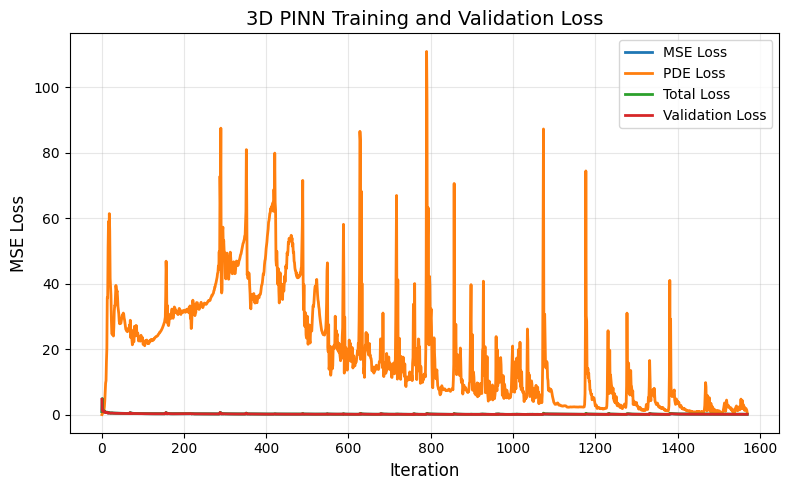

In [20]:
plot_training_logs(logs_adam, title="3D PINN Training and Validation Loss")

In [21]:
### Cell 15: Calculate L2 Error on Training Data ###
model.eval()
with torch.no_grad():
    # Predict on the full dataset
    x_all_tensor = torch.tensor(X_all, dtype=torch.float32).to(device)
    y_pred_scaled = model(x_all_tensor)

# Convert predictions and ground truth back to original scale
y_pred_orig = y_scaler.inverse_transform(y_pred_scaled.cpu().numpy())
y_true_orig = y_scaler.inverse_transform(y_all_tensor.cpu().numpy())



# ---- Compute metrics per component ----
mae = np.mean(np.abs(y_pred_orig - y_true_orig), axis=0)
mse = np.mean((y_pred_orig - y_true_orig) ** 2, axis=0)
l2 = np.linalg.norm(y_pred_orig - y_true_orig, axis=0) / np.linalg.norm(y_true_orig, axis=0)





# ---- Print results ----
components = ['U_x', 'U_y', 'U_z', 'p']
print("\n=== Full-Dataset Evaluation ===")
for i, comp in enumerate(components):
    print(f"{comp}: MAE = {mae[i]:.4f}, MSE = {mse[i]:.4f}, L2 = {l2[i]:.4f}")





# ---- Optional: Velocity magnitude evaluation ----
vel_pred = np.sqrt(np.sum(y_pred_orig[:, :3] ** 2, axis=1))
vel_true = np.sqrt(np.sum(y_true_orig[:, :3] ** 2, axis=1))

mae_vel = np.mean(np.abs(vel_pred - vel_true))
mse_vel = np.mean((vel_pred - vel_true) ** 2)
l2_vel = np.linalg.norm(vel_pred - vel_true) / np.linalg.norm(vel_true)

print(f"\nVelocity Magnitude: MAE = {mae_vel:.4f}, MSE = {mse_vel:.4f}, L2 = {l2_vel:.4f}")


=== Full-Dataset Evaluation ===
U_x: MAE = 0.0915, MSE = 0.0135, L2 = 0.1427
U_y: MAE = 0.0244, MSE = 0.0009, L2 = 1.1877
U_z: MAE = 0.0017, MSE = 0.0000, L2 = 1.4069
p: MAE = 0.1168, MSE = 0.0188, L2 = 1.1734

Velocity Magnitude: MAE = 0.0913, MSE = 0.0135, L2 = 0.1424
